In [ ]:
import matplotlib.pyplot as plt
import cv2 as cv
from lcLevy.Image import Img
from skimage.measure import ransac, LineModelND
import numpy as np

patch_size = 50

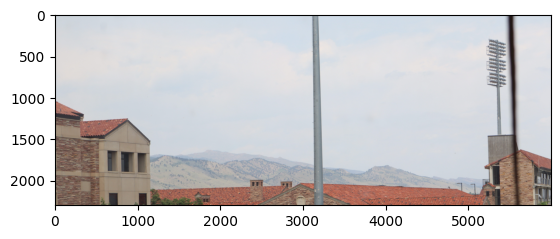

In [9]:
# Traverse over the pixels in the image in chunks
# Analyzing them two at a time just for the sake of this, but I think there
# are probably better solutions we can come up with eventually
# Especially with the need for interpolation

# Maybe make an array as like a map of what all the values are comparing the A_hat between all lateral patches
# Then somehow mesh this, if it's working decently



# Reading in the image
image = cv.imread("EOS_R100_JPG/jpg0005.jpg")
image = image[:,:,::-1]
image = image[:2300,:]
plt.imshow(image)

In [3]:
# Helper Functions

def lobf(pixels):
    pixels = pixels.reshape(patch_size**2, 3)
    # I'm guessing that the total range is 0-255, but don't really have proof of that
    fit, inliers= ransac(pixels, LineModelND, 200, 2, max_trials = 1000) 
    return (fit, inliers)

def display_lobf(lobf):
    """TO IMPLEMENT"""
    return None

def normalize(vec):
    l = np.sqrt(vec[0]**2 + vec[1]**2+vec[2]**2)
    return [vec[0]/l, vec[1]/l, vec[2]/l]

def airlight_direction(lobf_one, lobf_two):
    z1 = [50]
    z2 = [100]

    # points on plane 1
    pt1 = [lobf_one.predict_x(z1)[0], lobf_one.predict_y(z1)[0], z1[0]]
    pt2 = [lobf_one.predict_x(z2)[0], lobf_one.predict_y(z2)[0], z2[0]]
    norm_one = np.cross(pt1, pt2)
    # points on plane 2
    pt3 = [lobf_two.predict_x(z1)[0], lobf_two.predict_y(z1)[0], z1[0]]
    pt4 = [lobf_two.predict_x(z2)[0], lobf_two.predict_y(z2)[0], z2[0]]
    norm_two = np.cross(pt3, pt4)

    # This assumes, as I believe we can in this problem that the planes intersect at the origin
    intersect = np.cross(norm_one, norm_two)
    return normalize(intersect)

def airlight_mag(lobf):
    return np.sqrt(lobf.predict_x([0])**2 + lobf.predict_y([0])**2)[0]

def apply_shift(patch, dir, mag):
    red_frac = dir[0]**2
    green_frac = dir[1]**2
    blue_frac = dir[2]**2

    patch = patch.copy()

    for i in range(len(patch)):
        for j in range(len(patch[0])):
            patch[i][j][0]-= red_frac*mag
            patch[i][j][1]-= green_frac*mag
            patch[i][j][2] -= blue_frac*mag

    return patch





In [ ]:
# Actually iterating through the image
for row in range(0, len(image[0]), patch_size):
    for col in range(0, len(image), patch_size*2):
        # print(row, col)
        patch_one = image[row:row+patch_size,col:col+patch_size]
        patch_two = image[row:row+patch_size,col+patch_size: col+patch_size*2]

        l1 = lobf(patch_one)[0]
        l2 = lobf(patch_two)[0]

        A_hat = airlight_direction(l1, l2)
        a_1 = airlight_mag(l1)
        a_2 = airlight_mag(l2)
        image[row:row+patch_size,col:col+patch_size] = apply_shift(patch_one, A_hat, a_1)
        image[row:row+patch_size,col+patch_size:col+patch_size*2] = apply_shift(patch_two, A_hat, a_2)




C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:46: RuntimeWarning: invalid value encountered in cast
  patch[i][j][0]-= red_frac*mag
C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:47: RuntimeWarning: invalid value encountered in cast
  patch[i][j][1]-= green_frac*mag
C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:48: RuntimeWarning: invalid value encountered in cast
  patch[i][j][2] -= blue_frac*mag
C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return [vec[0]/l, vec[1]/l, vec[2]/l]
C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:46: RuntimeWarning: invalid value encountered in cast
  patch[i][j][0]-= red_frac*mag
C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:47: RuntimeWarning: invalid value encountered in cast
  patch[i][j][1]-= green_frac*mag
C:\Users\cct22\AppData\Local\Temp\ipykernel_26428\4083401209.py:48: RuntimeWa